# Head-to-Head (H2H) Performance Analysis Plan

1. Data Model & Key Definition
   - Use `EventID` as the natural key to identify each race instance.
   - Source table: `race_results` with athlete_id, overall position, and split times.

2. Extraction
   - Query the database to pull relevant columns (EventID, athlete_id, Position, split times) since a configurable date.

3. Pair Generation
   - Self-join on `EventID` to create unordered athlete pairs (athlete_id_a < athlete_id_b).

4. Metric Calculations
   - Compute win flags: `win_a = Position_a < Position_b`.
   - Compute split time deltas: swim, bike, run, transitions.

5. Aggregation
   - Group by (`athlete_id_a`, `athlete_id_b`).
   - Calculate: matches count, wins, win_pct, average time gaps.

6. Loading & Integration
   - Store results in a `h2h_summary` table (upsert incrementally).
   - Ensure indices on athlete pairs for fast queries.

7. Consumption in Power BI
   - Import `h2h_summary` as a fact table.
   - Build matrix visuals with athlete₁ on rows, athlete₂ on columns, and measures (wins, win_pct, gaps).

8. Considerations
   - Performance: use SQL self-join or Dask for large volumes.
   - Incrementals: track last processed EventDate to handle new data only.
   - Extensibility: add metrics like max gap, last race date, and split-specific win_pct.

In [41]:
import pandas as pd
from database import get_engine

engine = get_engine()
df = pd.read_sql("""
    SELECT
      event_id,
      athlete_id,
      prog_id,
      position
    FROM race_results
""", engine)

# Load split rankings from position_metrics and merge with race_results
df_metrics = pd.read_sql("""
    SELECT
      event_id,
      athlete_id,
      prog_id,
      swimrank,
      t1rank,
      bikerank,
      t2rank,
      runrank
    FROM position_metrics
""", engine)

# Merge split rankings into main race results DataFrame
# (Assumes df is your main race_results DataFrame)
df = df.merge(df_metrics, on=["event_id", "athlete_id", "prog_id"], how="left")

df

,event_id,athlete_id,prog_id,position,swimrank,t1rank,bikerank,t2rank,runrank
0,184790,23656,628673,1,11.0,1.0,5.0,3.0,1.0
1,184790,39560,628673,2,10.0,6.0,1.0,1.0,4.0
2,184790,18332,628673,3,5.0,13.0,3.0,18.0,5.0
3,184790,75822,628673,4,2.0,13.0,15.0,6.0,3.0
4,184790,12773,628673,5,14.0,1.0,11.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...
119299,194983,161291,675818,13,15.0,9.0,16.0,11.0,9.0
119300,194983,198064,675818,14,16.0,16.0,14.0,13.0,11.0
119301,194983,190131,675818,15,13.0,14.0,15.0,NaN,NaN
119302,194983,172674,675818,DNF,4.0,4.0,1.0,3.0,NaN


In [43]:
# create every A vs B in the same event/program
df_pairs = (
  df.merge(df, on=["prog_id"], suffixes=("_a", "_b"))
    .query("athlete_id_a < athlete_id_b")  # unordered pairs only once
)

# Win flags for overall and each segment
df_pairs["win_a"]       = df_pairs["position_a"]   < df_pairs["position_b"]
df_pairs["win_swim_a"]  = df_pairs["swimrank_a"]    < df_pairs["swimrank_b"]
df_pairs["win_t1_a"]    = df_pairs["t1rank_a"]      < df_pairs["t1rank_b"]
df_pairs["win_bike_a"]  = df_pairs["bikerank_a"]    < df_pairs["bikerank_b"]
df_pairs["win_t2_a"]    = df_pairs["t2rank_a"]      < df_pairs["t2rank_b"]
df_pairs["win_run_a"]   = df_pairs["runrank_a"]     < df_pairs["runrank_b"]

df_pairs.columns


Index(['event_id_a', 'athlete_id_a', 'prog_id', 'position_a', 'swimrank_a',
       't1rank_a', 'bikerank_a', 't2rank_a', 'runrank_a', 'event_id_b',
       'athlete_id_b', 'position_b', 'swimrank_b', 't1rank_b', 'bikerank_b',
       't2rank_b', 'runrank_b', 'win_a', 'win_swim_a', 'win_t1_a',
       'win_bike_a', 'win_t2_a', 'win_run_a'],
      dtype='object')

In [ ]:
# Aggregate H2H metrics by athlete pair
h2h = (
  df_pairs
    .groupby(["athlete_id_a", "athlete_id_b"])
    .agg(
      matches       = ("prog_id",      "count"),
      wins_overall  = ("win_a",        "sum"),
      wins_swim     = ("win_swim_a",   "sum"),
      wins_t1       = ("win_t1_a",     "sum"),
      wins_bike     = ("win_bike_a",   "sum"),
      wins_t2       = ("win_t2_a",     "sum"),
      wins_run      = ("win_run_a",    "sum"),
    )
    .reset_index()
)

# Calculate win percentages
h2h["win_pct_overall"] = h2h["wins_overall"] / h2h["matches"]
h2h["win_pct_swim"]    = h2h["wins_swim"]    / h2h["matches"]
h2h["win_pct_t1"]      = h2h["wins_t1"]      / h2h["matches"]
h2h["win_pct_bike"]    = h2h["wins_bike"]    / h2h["matches"]
h2h["win_pct_t2"]      = h2h["wins_t2"]      / h2h["matches"]
h2h["win_pct_run"]     = h2h["wins_run"]     / h2h["matches"]


,athlete_id_a,athlete_id_b,matches,wins_a,win_pct_a
0,5296,5297,26,11,0.423077
1,5296,5298,4,1,0.250000
2,5296,5302,14,6,0.428571
3,5296,5303,1,0,0.000000
4,5296,5305,17,6,0.352941
...,...,...,...,...,...
1105120,198002,198164,1,0,0.000000
1105121,198002,198204,1,0,0.000000
1105122,198063,198164,1,0,0.000000
1105123,198063,198204,1,0,0.000000


In [31]:
# Compute wins and win percentages for athlete B
h2h['wins_overall_b'] = h2h['matches'] - h2h['wins_overall']
h2h['wins_swim_b']    = h2h['matches'] - h2h['wins_swim']
h2h['wins_t1_b']      = h2h['matches'] - h2h['wins_t1']
h2h['wins_bike_b']    = h2h['matches'] - h2h['wins_bike']
h2h['wins_t2_b']      = h2h['matches'] - h2h['wins_t2']
h2h['wins_run_b']     = h2h['matches'] - h2h['wins_run']

# Compute win percentage for athlete B
h2h['win_pct_overall_b'] = h2h['wins_overall_b'] / h2h['matches']
h2h['win_pct_swim_b']    = h2h['wins_swim_b']    / h2h['matches']
h2h['win_pct_t1_b']      = h2h['wins_t1_b']      / h2h['matches']
h2h['win_pct_bike_b']    = h2h['wins_bike_b']    / h2h['matches']
h2h['win_pct_t2_b']      = h2h['wins_t2_b']      / h2h['matches']
h2h['win_pct_run_b']     = h2h['wins_run_b']     / h2h['matches']

h2h.head()

,athlete_id_a,athlete_id_b,matches,wins_overall,wins_swim,wins_t1,wins_bike,wins_t2,wins_run,win_pct_overall,...,wins_t1_b,wins_bike_b,wins_t2_b,wins_run_b,win_pct_overall_b,win_pct_swim_b,win_pct_t1_b,win_pct_bike_b,win_pct_t2_b,win_pct_run_b
0,5296,5297,26,11,19,13,9,9,7,0.423077,...,13,17,17,19,0.576923,0.269231,0.500000,0.653846,0.653846,0.730769
1,5296,5298,4,1,3,3,1,3,1,0.250000,...,1,3,1,3,0.750000,0.250000,0.250000,0.750000,0.250000,0.750000
2,5296,5302,14,6,5,7,9,7,3,0.428571,...,7,5,7,11,0.571429,0.642857,0.500000,0.357143,0.500000,0.785714
3,5296,5303,1,0,1,0,1,0,0,0.000000,...,1,0,1,1,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000
4,5296,5305,17,6,12,7,5,8,4,0.352941,...,10,12,9,13,0.647059,0.294118,0.588235,0.705882,0.529412,0.764706


In [39]:
h2h

,athlete_id_a,athlete_id_b,matches,wins_overall,wins_swim,wins_t1,wins_bike,wins_t2,wins_run,win_pct_overall,...,wins_t1_b,wins_bike_b,wins_t2_b,wins_run_b,win_pct_overall_b,win_pct_swim_b,win_pct_t1_b,win_pct_bike_b,win_pct_t2_b,win_pct_run_b
0,5296,5297,26,11,19,13,9,9,7,0.423077,...,13,17,17,19,0.576923,0.269231,0.500000,0.653846,0.653846,0.730769
1,5296,5298,4,1,3,3,1,3,1,0.250000,...,1,3,1,3,0.750000,0.250000,0.250000,0.750000,0.250000,0.750000
2,5296,5302,14,6,5,7,9,7,3,0.428571,...,7,5,7,11,0.571429,0.642857,0.500000,0.357143,0.500000,0.785714
3,5296,5303,1,0,1,0,1,0,0,0.000000,...,1,0,1,1,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000
4,5296,5305,17,6,12,7,5,8,4,0.352941,...,10,12,9,13,0.647059,0.294118,0.588235,0.705882,0.529412,0.764706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105120,198002,198164,1,0,0,1,0,0,0,0.000000,...,0,1,1,1,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
1105121,198002,198204,1,0,0,1,0,0,0,0.000000,...,0,1,1,1,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
1105122,198063,198164,1,0,0,1,0,0,0,0.000000,...,0,1,1,1,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
1105123,198063,198204,1,0,0,0,0,0,0,0.000000,...,1,1,1,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


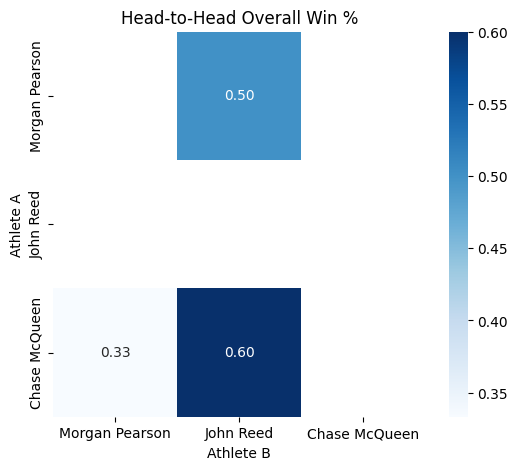

In [36]:
# Visualize H2H overall win percentage matrix for selected athletes
import seaborn as sns
import matplotlib.pyplot as plt

# Fetch athlete IDs for the chosen names
athlete_df = pd.read_sql("SELECT athlete_id, full_name FROM athlete", engine)
names = ["Morgan Pearson", "John Reed", "Chase McQueen"]
ids = athlete_df.loc[athlete_df['full_name'].isin(names), 'athlete_id'].tolist()

# Filter H2H for selected athlete pairs
h2h_sub = h2h[h2h['athlete_id_a'].isin(ids) & h2h['athlete_id_b'].isin(ids)]

# Pivot the win_pct_overall into a matrix
pivot = h2h_sub.pivot(index='athlete_id_a', columns='athlete_id_b', values='win_pct_overall')

# Map IDs back to full names
mapping = dict(zip(athlete_df['athlete_id'], athlete_df['full_name']))
pivot.index = pivot.index.map(mapping)
pivot.columns = pivot.columns.map(mapping)

# Ensure all selected athletes appear as both rows and columns
pivot = pivot.reindex(index=names, columns=names)

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, cmap='Blues', fmt='.2f', mask=pivot.isnull())
plt.title('Head-to-Head Overall Win %')
plt.ylabel('Athlete A')
plt.xlabel('Athlete B')
plt.show()

In [37]:
h2h_sub


,athlete_id_a,athlete_id_b,matches,wins_overall,wins_swim,wins_t1,wins_bike,wins_t2,wins_run,win_pct_overall,...,wins_t1_b,wins_bike_b,wins_t2_b,wins_run_b,win_pct_overall_b,win_pct_swim_b,win_pct_t1_b,win_pct_bike_b,win_pct_t2_b,win_pct_run_b
768583,96667,123392,9,3,5,2,7,6,1,0.333333,...,7,2,3,8,0.666667,0.444444,0.777778,0.222222,0.333333,0.888889
768714,96667,164894,10,6,9,6,5,10,2,0.600000,...,4,5,0,8,0.400000,0.100000,0.400000,0.500000,0.000000,0.800000
903080,123392,164894,4,2,1,3,2,3,3,0.500000,...,1,2,1,1,0.500000,0.750000,0.250000,0.500000,0.250000,0.250000


In [38]:
# Store the filtered H2H pairs table for dynamic filtering in Power BI
h2h_sub.to_sql("h2h_pairs", engine, if_exists="replace", index=False)
print("Stored 'h2h_pairs' table to the database.")

Stored 'h2h_pairs' table to the database.
